In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import yfinance as yf
import ta
import warnings
warnings.filterwarnings('ignore')

# Paramètres graphique
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor']   = '#0d1117'
plt.rcParams['axes.edgecolor']   = '#30363d'
plt.rcParams['text.color']       = '#e6edf3'
plt.rcParams['axes.labelcolor']  = '#e6edf3'
plt.rcParams['xtick.color']      = '#8b949e'
plt.rcParams['ytick.color']      = '#8b949e'
plt.rcParams['grid.color']       = '#21262d'
plt.rcParams['grid.linewidth']   = 0.5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

# Télécharger SPY
df = yf.download("SPY", start="2024-01-01", progress=False)
df.columns = [col[0] for col in df.columns]
df = df.dropna()

# Garder les 120 derniers jours pour la visualisation
df_viz = df.tail(120).copy()

print(f"Données : {len(df_viz)} jours")
print(f"Période : {df_viz.index[0].date()} → {df_viz.index[-1].date()}")

Device : cuda
Données : 120 jours
Période : 2025-11-03 → 2026-04-27


In [2]:
def calculate_smc_features(df, swing_window=10, ob_window=5):
    d = df.copy()

    # ── 1. SWING HIGHS / SWING LOWS ──────────────────────────
    # Un swing high = bougie dont le High est le plus haut sur N jours
    # Un swing low  = bougie dont le Low  est le plus bas  sur N jours
    d['swing_high'] = d['High'][(
        d['High'] == d['High'].rolling(swing_window, center=True).max()
    )]
    d['swing_low'] = d['Low'][(
        d['Low'] == d['Low'].rolling(swing_window, center=True).min()
    )]

    # ── 2. BSL / SSL ──────────────────────────────────────────
    # BSL = Buy Side Liquidity  = au-dessus des swing highs récents
    # SSL = Sell Side Liquidity = en-dessous des swing lows récents
    d['bsl_level'] = d['swing_high'].ffill()  # dernier swing high
    d['ssl_level'] = d['swing_low'].ffill()   # dernier swing low

    # Distance relative au BSL et SSL (feature numérique pour ML)
    d['bsl_distance'] = (d['bsl_level'] - d['Close']) / d['Close']
    d['ssl_distance'] = (d['Close'] - d['ssl_level']) / d['Close']

    # ── 3. ORDER BLOCKS ───────────────────────────────────────
    # Bullish OB = dernière bougie rouge avant forte hausse
    # Bearish OB = dernière bougie verte avant forte baisse
    d['body']         = abs(d['Close'] - d['Open'])
    d['avg_body']     = d['body'].rolling(20).mean()
    d['big_move']     = d['body'] > 1.5 * d['avg_body']
    d['bull_candle']  = d['Close'] > d['Open']
    d['bear_candle']  = d['Close'] < d['Open']

    # OB haussier : bougie rouge suivie d'une grosse bougie verte
    d['ob_bullish'] = (
        d['bear_candle'] &
        d['bull_candle'].shift(-1) &
        d['big_move'].shift(-1)
    ).astype(int)

    # OB baissier : bougie verte suivie d'une grosse bougie rouge
    d['ob_bearish'] = (
        d['bull_candle'] &
        d['bear_candle'].shift(-1) &
        d['big_move'].shift(-1)
    ).astype(int)

    # Niveaux des OB pour le graphique
    d['ob_bull_high'] = np.where(d['ob_bullish'], d['High'], np.nan)
    d['ob_bull_low']  = np.where(d['ob_bullish'], d['Low'],  np.nan)
    d['ob_bear_high'] = np.where(d['ob_bearish'], d['High'], np.nan)
    d['ob_bear_low']  = np.where(d['ob_bearish'], d['Low'],  np.nan)

    # ── 4. FAIR VALUE GAP (FVG) ───────────────────────────────
    # FVG haussier : Low[J] > High[J-2] → gap entre bougie J-2 et J
    # FVG baissier : High[J] < Low[J-2] → gap entre bougie J-2 et J
    d['fvg_bullish'] = (d['Low'] > d['High'].shift(2)).astype(int)
    d['fvg_bearish'] = (d['High'] < d['Low'].shift(2)).astype(int)

    d['fvg_bull_top']    = np.where(d['fvg_bullish'], d['Low'],        np.nan)
    d['fvg_bull_bottom'] = np.where(d['fvg_bullish'], d['High'].shift(2), np.nan)
    d['fvg_bear_top']    = np.where(d['fvg_bearish'], d['Low'].shift(2), np.nan)
    d['fvg_bear_bottom'] = np.where(d['fvg_bearish'], d['High'],       np.nan)

    # ── 5. LIQUIDITY SWEEP ────────────────────────────────────
    # Prix dépasse un swing puis clôture en sens inverse = chasse confirmée
    d['liq_sweep_bull'] = (
        (d['Low']  < d['ssl_level'].shift(1)) &
        (d['Close'] > d['ssl_level'].shift(1))
    ).astype(int)

    d['liq_sweep_bear'] = (
        (d['High'] > d['bsl_level'].shift(1)) &
        (d['Close'] < d['bsl_level'].shift(1))
    ).astype(int)

    # ── 6. CHoCH — Change of Character ────────────────────────
    # Rupture de la structure : nouveau swing high/low cassé
    d['choch_bull'] = (
        (d['Close'] > d['bsl_level'].shift(1)) &
        (d['Close'].shift(1) < d['bsl_level'].shift(1))
    ).astype(int)

    d['choch_bear'] = (
        (d['Close'] < d['ssl_level'].shift(1)) &
        (d['Close'].shift(1) > d['ssl_level'].shift(1))
    ).astype(int)

    return d

# Appliquer les features SMC
df_smc = calculate_smc_features(df_viz)

# Résumé
print("Features SMC calculées :")
print(f"  Order Blocks haussiers : {df_smc['ob_bullish'].sum()}")
print(f"  Order Blocks baissiers : {df_smc['ob_bearish'].sum()}")
print(f"  FVG haussiers          : {df_smc['fvg_bullish'].sum()}")
print(f"  FVG baissiers          : {df_smc['fvg_bearish'].sum()}")
print(f"  Liquidity sweeps bull  : {df_smc['liq_sweep_bull'].sum()}")
print(f"  Liquidity sweeps bear  : {df_smc['liq_sweep_bear'].sum()}")
print(f"  CHoCH haussiers        : {df_smc['choch_bull'].sum()}")
print(f"  CHoCH baissiers        : {df_smc['choch_bear'].sum()}")

Features SMC calculées :
  Order Blocks haussiers : 5
  Order Blocks baissiers : 3
  FVG haussiers          : 22
  FVG baissiers          : 15
  Liquidity sweeps bull  : 7
  Liquidity sweeps bear  : 6
  CHoCH haussiers        : 7
  CHoCH baissiers        : 4


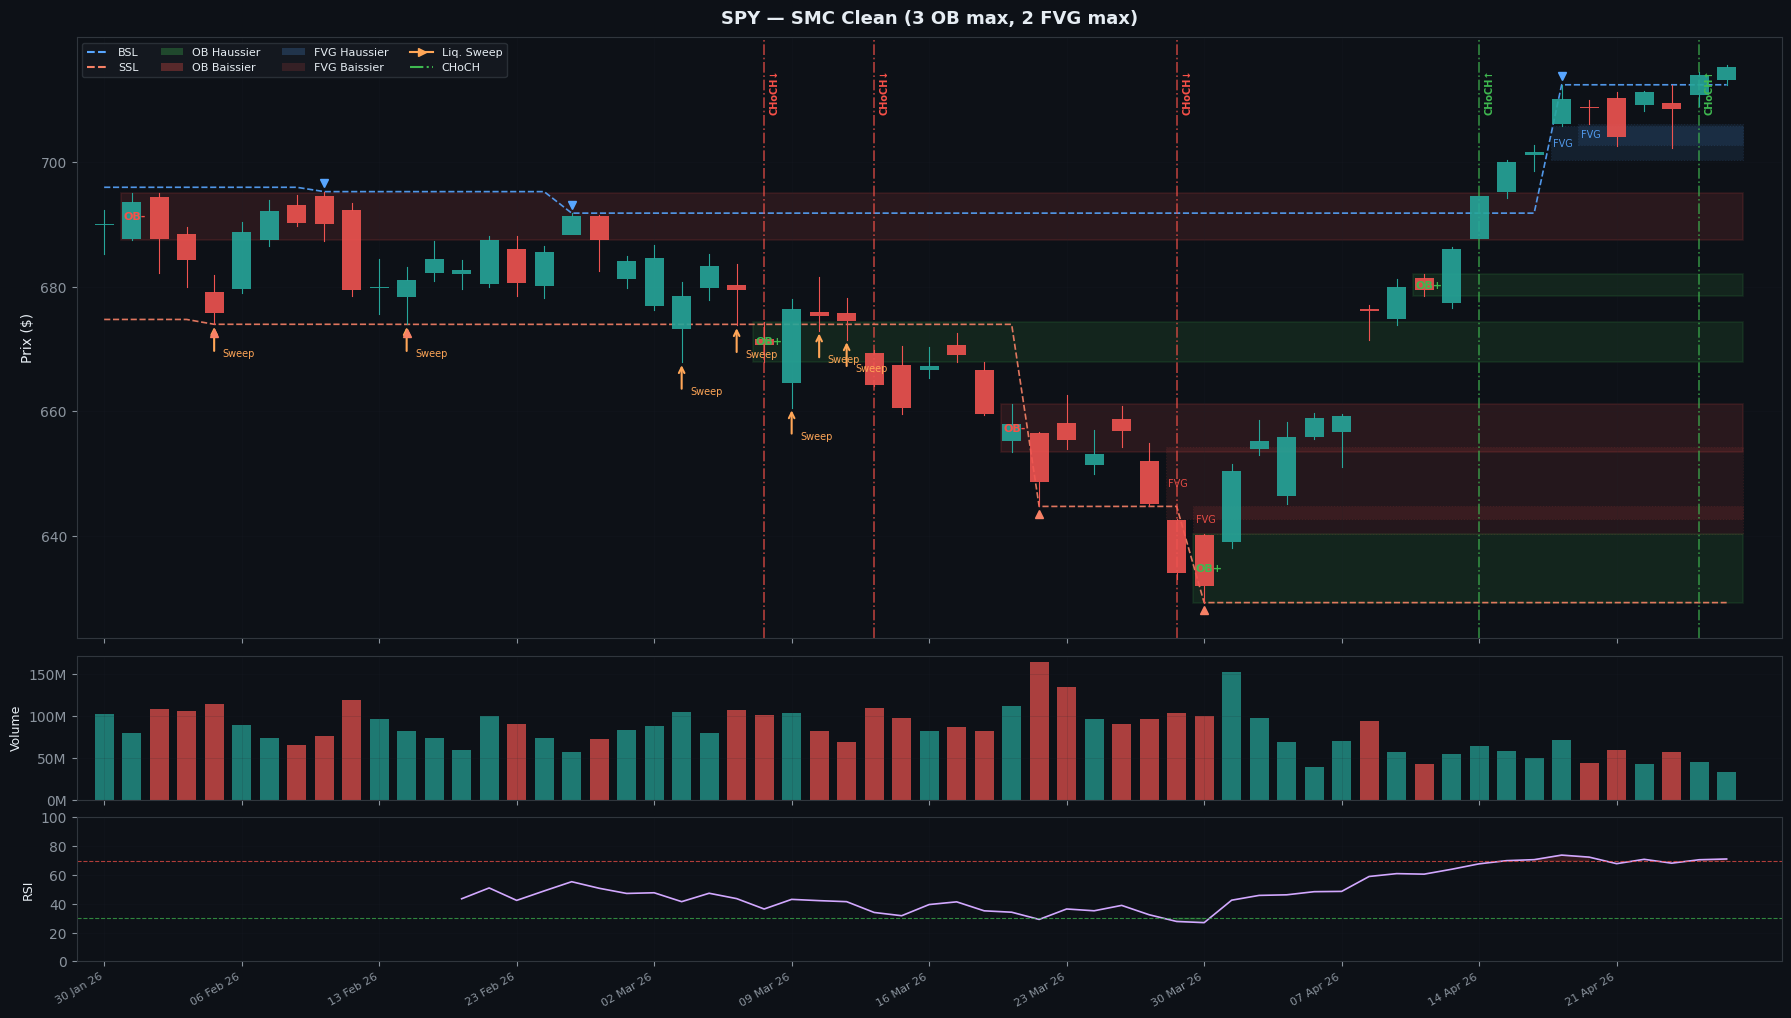

Graphique sauvegardé : smc_chart_clean.png


In [4]:
def plot_smc_clean(df, title="SPY — Smart Money Concepts", n_days=60):
    d = df.tail(n_days).copy().reset_index()
    idx = np.arange(len(d))

    fig = plt.figure(figsize=(22, 12))
    gs  = gridspec.GridSpec(3, 1,
                            height_ratios=[5, 1.2, 1.2],
                            hspace=0.06)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)

    # ── BOUGIES ───────────────────────────────────────────────
    for i, row in d.iterrows():
        is_bull = row['Close'] >= row['Open']
        color   = '#26a69a' if is_bull else '#ef5350'
        body_b  = min(row['Open'], row['Close'])
        body_h  = max(row['Open'], row['Close'])
        ax1.bar(i, body_h - body_b, bottom=body_b,
                color=color, width=0.7, alpha=0.9, zorder=3)
        ax1.plot([i, i], [row['Low'],  body_b],
                 color=color, linewidth=0.8, zorder=3)
        ax1.plot([i, i], [body_h, row['High']],
                 color=color, linewidth=0.8, zorder=3)

    # ── BSL / SSL LIGNES ──────────────────────────────────────
    ax1.plot(idx, d['bsl_level'].values,
             color='#58a6ff', linewidth=1.2,
             linestyle='--', alpha=0.9,
             label='BSL', zorder=2)
    ax1.plot(idx, d['ssl_level'].values,
             color='#f78166', linewidth=1.2,
             linestyle='--', alpha=0.9,
             label='SSL', zorder=2)

    # ── SWING HIGHS / LOWS — seulement les marqueurs ─────────
    for i, row in d.iterrows():
        if not pd.isna(row.get('swing_high', np.nan)):
            ax1.plot(i, row['High'] * 1.002,
                    marker='v', color='#58a6ff',
                    markersize=6, zorder=4)
        if not pd.isna(row.get('swing_low', np.nan)):
            ax1.plot(i, row['Low'] * 0.998,
                    marker='^', color='#f78166',
                    markersize=6, zorder=4)

    # ── ORDER BLOCKS — seulement les 3 derniers de chaque ────
    ob_bull_idx = d[d['ob_bullish'] == 1].tail(3).index.tolist()
    ob_bear_idx = d[d['ob_bearish'] == 1].tail(3).index.tolist()

    for i in ob_bull_idx:
        row = d.loc[i]
        # Zone colorée jusqu'à la fin du graphique
        rect = plt.Rectangle(
            (i - 0.4, row['Low']),
            len(d) - i,
            row['High'] - row['Low'],
            linewidth=1.2, edgecolor='#3fb950',
            facecolor='#3fb950', alpha=0.12,
            zorder=1
        )
        ax1.add_patch(rect)
        # Label sobre à gauche de la zone
        ax1.text(i - 0.3, (row['High'] + row['Low']) / 2,
                'OB+', fontsize=8, color='#3fb950',
                fontweight='bold', va='center', zorder=5)

    for i in ob_bear_idx:
        row = d.loc[i]
        rect = plt.Rectangle(
            (i - 0.4, row['Low']),
            len(d) - i,
            row['High'] - row['Low'],
            linewidth=1.2, edgecolor='#f85149',
            facecolor='#f85149', alpha=0.12,
            zorder=1
        )
        ax1.add_patch(rect)
        ax1.text(i - 0.3, (row['High'] + row['Low']) / 2,
                'OB-', fontsize=8, color='#f85149',
                fontweight='bold', va='center', zorder=5)

    # ── FVG — seulement les 2 derniers de chaque ─────────────
    fvg_bull_idx = d[d['fvg_bullish'] == 1].tail(2).index.tolist()
    fvg_bear_idx = d[d['fvg_bearish'] == 1].tail(2).index.tolist()

    for i in fvg_bull_idx:
        row = d.loc[i]
        if not pd.isna(row['fvg_bull_top']) and \
           not pd.isna(row['fvg_bull_bottom']):
            h = row['fvg_bull_top'] - row['fvg_bull_bottom']
            if h > 0:
                rect = plt.Rectangle(
                    (i - 0.4, row['fvg_bull_bottom']),
                    len(d) - i, h,
                    linewidth=0.8, edgecolor='#58a6ff',
                    facecolor='#58a6ff', alpha=0.10,
                    linestyle=':', zorder=1
                )
                ax1.add_patch(rect)
                ax1.text(i - 0.3, row['fvg_bull_bottom'] + h/2,
                        'FVG', fontsize=7,
                        color='#58a6ff', va='center',
                        alpha=0.9, zorder=5)

    for i in fvg_bear_idx:
        row = d.loc[i]
        if not pd.isna(row['fvg_bear_top']) and \
           not pd.isna(row['fvg_bear_bottom']):
            h = row['fvg_bear_top'] - row['fvg_bear_bottom']
            if h > 0:
                rect = plt.Rectangle(
                    (i - 0.4, row['fvg_bear_bottom']),
                    len(d) - i, h,
                    linewidth=0.8, edgecolor='#f85149',
                    facecolor='#f85149', alpha=0.10,
                    linestyle=':', zorder=1
                )
                ax1.add_patch(rect)
                ax1.text(i - 0.3, row['fvg_bear_bottom'] + h/2,
                        'FVG', fontsize=7,
                        color='#f85149', va='center',
                        alpha=0.9, zorder=5)

    # ── LIQUIDITY SWEEPS ──────────────────────────────────────
    for i, row in d.iterrows():
        if row['liq_sweep_bull']:
            ax1.annotate('', xy=(i, row['Low']),
                        xytext=(i, row['Low'] * 0.993),
                        arrowprops=dict(
                            arrowstyle='->', color='#ffa657',
                            lw=1.5))
            ax1.text(i + 0.3, row['Low'] * 0.993,
                    'Sweep', fontsize=7,
                    color='#ffa657', va='center')

        if row['liq_sweep_bear']:
            ax1.annotate('', xy=(i, row['High']),
                        xytext=(i, row['High'] * 1.005),
                        arrowprops=dict(
                            arrowstyle='->', color='#ffa657',
                            lw=1.5))
            ax1.text(i + 0.3, row['High'] * 1.005,
                    'Sweep', fontsize=7,
                    color='#ffa657', va='center')

    # ── CHoCH ─────────────────────────────────────────────────
    for i, row in d.iterrows():
        if row['choch_bull']:
            ax1.axvline(x=i, color='#3fb950',
                       linewidth=1.2, linestyle='-.',
                       alpha=0.7, zorder=2)
            ax1.text(i + 0.2, d['High'].max() * 0.999,
                    'CHoCH↑', fontsize=7,
                    color='#3fb950', fontweight='bold',
                    rotation=90, va='top')

        if row['choch_bear']:
            ax1.axvline(x=i, color='#f85149',
                       linewidth=1.2, linestyle='-.',
                       alpha=0.7, zorder=2)
            ax1.text(i + 0.2, d['High'].max() * 0.999,
                    'CHoCH↓', fontsize=7,
                    color='#f85149', fontweight='bold',
                    rotation=90, va='top')

    # ── AXE PRIX ──────────────────────────────────────────────
    ax1.set_title(title, fontsize=13,
                 fontweight='bold', pad=10,
                 color='#e6edf3')
    ax1.grid(True, alpha=0.2, zorder=0)
    ax1.set_ylabel('Prix ($)', fontsize=10)
    ax1.set_xlim(-1, len(d) + 1)
    plt.setp(ax1.get_xticklabels(), visible=False)

    # Légende épurée
    legend_elements = [
        plt.Line2D([0],[0], color='#58a6ff',
                  linestyle='--', label='BSL'),
        plt.Line2D([0],[0], color='#f78166',
                  linestyle='--', label='SSL'),
        mpatches.Patch(facecolor='#3fb950',
                      alpha=0.3, label='OB Haussier'),
        mpatches.Patch(facecolor='#f85149',
                      alpha=0.3, label='OB Baissier'),
        mpatches.Patch(facecolor='#58a6ff',
                      alpha=0.2, label='FVG Haussier'),
        mpatches.Patch(facecolor='#f85149',
                      alpha=0.15, label='FVG Baissier'),
        plt.Line2D([0],[0], color='#ffa657',
                  marker='>', label='Liq. Sweep'),
        plt.Line2D([0],[0], color='#3fb950',
                  linestyle='-.', label='CHoCH'),
    ]
    ax1.legend(handles=legend_elements,
              loc='upper left', fontsize=8,
              facecolor='#161b22',
              edgecolor='#30363d',
              ncol=4)

    # ── VOLUME ────────────────────────────────────────────────
    vol_colors = [
        '#26a69a' if d['Close'].iloc[i] >= d['Open'].iloc[i]
        else '#ef5350' for i in range(len(d))
    ]
    ax2.bar(idx, d['Volume'].values,
            color=vol_colors, alpha=0.7, width=0.7)
    ax2.set_ylabel('Volume', fontsize=9)
    ax2.grid(True, alpha=0.2)
    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
    plt.setp(ax2.get_xticklabels(), visible=False)

    # ── RSI ───────────────────────────────────────────────────
    rsi = ta.momentum.RSIIndicator(
        d['Close'], window=14).rsi()
    ax3.plot(idx, rsi.values,
             color='#d2a8ff', linewidth=1.2)
    ax3.axhline(70, color='#f85149',
                linestyle='--', linewidth=0.8, alpha=0.7)
    ax3.axhline(30, color='#3fb950',
                linestyle='--', linewidth=0.8, alpha=0.7)
    ax3.fill_between(idx, rsi.values, 70,
                     where=rsi.values >= 70,
                     color='#f85149', alpha=0.15)
    ax3.fill_between(idx, rsi.values, 30,
                     where=rsi.values <= 30,
                     color='#3fb950', alpha=0.15)
    ax3.set_ylabel('RSI', fontsize=9)
    ax3.set_ylim(0, 100)
    ax3.grid(True, alpha=0.2)

    # Dates
    step = max(1, len(d) // 12)
    ticks = list(range(0, len(d), step))
    ax3.set_xticks(ticks)
    ax3.set_xticklabels(
        [d['Date'].iloc[i].strftime('%d %b %y')
         if 'Date' in d.columns
         else d.index[i].strftime('%d %b %y')
         for i in ticks],
        fontsize=8, rotation=30, ha='right'
    )

    plt.tight_layout()
    plt.savefig('smc_chart_clean.png',
                dpi=150, bbox_inches='tight',
                facecolor='#0d1117')
    plt.show()
    print("Graphique sauvegardé : smc_chart_clean.png")

# Lancer
plot_smc_clean(df_smc,
    title="SPY — SMC Clean (3 OB max, 2 FVG max)",
    n_days=60)